# Gaussian Process multi-objective hyperparameter experiment

This notebook tests a GP-compatible version of the cumulative NBS idea.

Unlike the neural-network experiment, we are **not** adding a custom training loss. Instead, we use an outer multi-objective optimizer to search over GP hyperparameters and select models that balance:

1. monthly NBS RMSE
2. 6-month integrated NBS RMSE

This is based on the current production GP structure:

```python
kernel = 1.0 * Matern(nu=1.5) * RationalQuadratic()
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.1)
```

The experiment keeps the model close to production while changing how candidate GP configurations are selected.

## 1. Install optional dependency

In [1]:
# Uncomment if needed.
%pip install platypus-opt

Note: you may need to restart the kernel to use updated packages.


## 2. Imports and setup

In [2]:
import os
import sys
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic
from sklearn.metrics import mean_squared_error, r2_score

from platypus import NSGAII, Problem, Real

import joblib

In [3]:
sys.path.append(os.path.abspath("../../"))

from src.data_processor import CFSTransformer
from src.data_loader import DataLoader

## 3. User inputs

In [4]:
local_path = "/Users/dannes/Documents/cnbs-predictor-dev/"
input_dir = local_path + "cnbs-predictor/data/"

train_start_date = "1981-09-01"
train_end_date = "2005-12-01"

val_start_date = "2006-01-01"
val_end_date = "2010-03-01"

random_state = 42

lakes = ["superior", "michigan-huron", "erie", "ontario"]

# Keep this modest at first. GP fitting is expensive.
nsgaii_evaluations = 20

## 4. Load CFSR features

In [5]:
pcp_data = pd.read_csv(input_dir + "cfsr/CFSR_APCP_Basin_Avgs.csv")
evap_data = pd.read_csv(input_dir + "cfsr/CFSR_EVAP_Basin_Avgs.csv")
tmp_data = pd.read_csv(input_dir + "cfsr/CFSR_TMP_Basin_Avgs.csv")

pcp_data["date"] = pd.to_datetime(pcp_data[["year", "month"]].assign(day=1))

X = pd.DataFrame({
    "superior_lake_precipitation": pcp_data["sup_lake"],
    "michigan-huron_lake_precipitation": pcp_data["mih_lake"],
    "erie_lake_precipitation": pcp_data["eri_lake"],
    "ontario_lake_precipitation": pcp_data["ont_lake"],

    "superior_land_precipitation": pcp_data["sup_land"],
    "michigan-huron_land_precipitation": pcp_data["mih_land"],
    "erie_land_precipitation": pcp_data["eri_land"],
    "ontario_land_precipitation": pcp_data["ont_land"],

    "superior_lake_evaporation": evap_data["sup_lake"],
    "michigan-huron_lake_evaporation": evap_data["mih_lake"],
    "erie_lake_evaporation": evap_data["eri_lake"],
    "ontario_lake_evaporation": evap_data["ont_lake"],

    "superior_land_evaporation": evap_data["sup_land"],
    "michigan-huron_land_evaporation": evap_data["mih_land"],
    "erie_land_evaporation": evap_data["eri_land"],
    "ontario_land_evaporation": evap_data["ont_land"],

    "superior_lake_air_temperature": tmp_data["sup_lake"],
    "michigan-huron_lake_air_temperature": tmp_data["mih_lake"],
    "erie_lake_air_temperature": tmp_data["eri_lake"],
    "ontario_lake_air_temperature": tmp_data["ont_lake"],

    "superior_land_air_temperature": tmp_data["sup_land"],
    "michigan-huron_land_air_temperature": tmp_data["mih_land"],
    "erie_land_air_temperature": tmp_data["eri_land"],
    "ontario_land_air_temperature": tmp_data["ont_land"],
})

X.set_index(pd.to_datetime(pcp_data[["year", "month"]].assign(day=1)), inplace=True)

X_shifted = CFSTransformer(X).shift_variables(lag=0, lead=10)

X_shifted = pd.concat(
    [
        X_shifted,
        pd.DataFrame({"month": X_shifted.index.month}, index=X_shifted.index),
    ],
    axis=1,
)

X_shifted = pd.get_dummies(X_shifted, columns=["month"], prefix="month")

feature_column_order = (
    [f"month_{i}" for i in range(1, 13)]
    + [
        f"{lake}_{surface_type}_{comp}_mo{m}"
        for lake in lakes
        for surface_type in ["lake", "land"]
        for comp in ["precipitation", "evaporation", "air_temperature"]
        for m in range(10)
    ]
)

X_reorg = X_shifted.reindex(columns=feature_column_order)

dataloader = DataLoader()
df_sst_k = dataloader.glsea(input_dir + "glsea/oisst_sst_1981-2024.csv", units="K")

X_merged = pd.merge(df_sst_k, X_reorg, left_index=True, right_index=True, how="inner")

print(X_merged.shape)
X_merged.head()

(343, 256)


,superior_sst,michigan-huron_sst,erie_sst,ontario_sst,month_1,month_2,month_3,month_4,month_5,month_6,...,ontario_land_air_temperature_mo0,ontario_land_air_temperature_mo1,ontario_land_air_temperature_mo2,ontario_land_air_temperature_mo3,ontario_land_air_temperature_mo4,ontario_land_air_temperature_mo5,ontario_land_air_temperature_mo6,ontario_land_air_temperature_mo7,ontario_land_air_temperature_mo8,ontario_land_air_temperature_mo9
date,,,,,,,,,,,,,,,,,,,,,
1981-09-01,289.16,292.925,295.60,293.36,False,False,False,False,False,False,...,286.578745,279.378374,275.202487,269.329360,261.010883,264.987021,270.307318,276.388563,286.613505,288.144814
1981-10-01,280.79,285.910,289.04,286.56,False,False,False,False,False,False,...,279.378374,275.202487,269.329360,261.010883,264.987021,270.307318,276.388563,286.613505,288.144814,293.056232
1981-11-01,279.02,281.815,284.75,283.00,False,False,False,False,False,False,...,275.202487,269.329360,261.010883,264.987021,270.307318,276.388563,286.613505,288.144814,293.056232,290.109434
1981-12-01,278.01,279.230,280.41,279.62,False,False,False,False,False,False,...,269.329360,261.010883,264.987021,270.307318,276.388563,286.613505,288.144814,293.056232,290.109434,287.470924
1982-01-01,276.40,276.885,275.64,275.59,True,False,False,False,False,False,...,261.010883,264.987021,270.307318,276.388563,286.613505,288.144814,293.056232,290.109434,287.470924,282.101856


## 5. Load targets

This mirrors the current production training file: precipitation, evaporation, runoff, and NBS are all included as targets.

The multi-objective evaluation will focus on NBS, but the GP is still trained on the full target vector to stay close to production.

In [6]:
l2 = dataloader.l2swbm(input_dir + "l2swbm/")
glcc = dataloader.glcc(input_dir + "glcc/", units="mm")

targets = pd.DataFrame({
    "superior_target_evaporation": l2["superior_evaporation_obs"],
    "superior_target_precipitation": l2["superior_precipitation_obs"],
    "superior_target_runoff": l2["superior_runoff_obs"],
    "superior_target_nbs": glcc["superior_nbs_obs"],

    "michigan-huron_target_evaporation": l2["michigan-huron_evaporation_obs"],
    "michigan-huron_target_precipitation": l2["michigan-huron_precipitation_obs"],
    "michigan-huron_target_runoff": l2["michigan-huron_runoff_obs"],
    "michigan-huron_target_nbs": glcc["michigan-huron_nbs_obs"],

    "erie_target_evaporation": l2["erie_evaporation_obs"],
    "erie_target_precipitation": l2["erie_precipitation_obs"],
    "erie_target_runoff": l2["erie_runoff_obs"],
    "erie_target_nbs": glcc["erie_nbs_obs"],

    "ontario_target_evaporation": l2["ontario_evaporation_obs"],
    "ontario_target_precipitation": l2["ontario_precipitation_obs"],
    "ontario_target_runoff": l2["ontario_runoff_obs"],
    "ontario_target_nbs": glcc["ontario_nbs_obs"],
}).dropna()

targets_lead = CFSTransformer(targets).shift_variables(lag=0, lead=12)

target_column_order = [
    f"{lake}_target_{comp}_mo{m}"
    for lake in lakes
    for comp in ["precipitation", "evaporation", "runoff", "nbs"]
    for m in range(12)
]

targets_reorg = targets_lead.reindex(columns=target_column_order)

aligned_X, aligned_y = X_merged.align(targets_reorg, join="inner", axis=0)

print(f"Number of features: {aligned_X.shape[1]}")
print(f"Number of targets: {aligned_y.shape[1]}")

Number of features: 256
Number of targets: 192


## 6. Train/test split and scaling

In [7]:
X_train = aligned_X[train_start_date:train_end_date]
y_train = aligned_y[train_start_date:train_end_date]

X_test = aligned_X[val_start_date:val_end_date]
y_test = aligned_y[val_start_date:val_end_date]

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

print(X_train_scaled.shape, y_train_scaled.shape)
print(X_test_scaled.shape, y_test_scaled.shape)

(292, 256) (292, 192)
(51, 256) (51, 192)


## 7. Evaluation helpers

In [8]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def unscale_to_df(y_scaled, scaler, index, columns):
    return pd.DataFrame(
        scaler.inverse_transform(y_scaled),
        index=index,
        columns=columns,
    )


def nbs_columns(columns):
    return [c for c in columns if "_target_nbs_mo" in c]


def monthly_nbs_rmse(y_true_df, y_pred_df):
    cols = nbs_columns(y_true_df.columns)
    yt = y_true_df[cols].to_numpy().ravel()
    yp = y_pred_df[cols].to_numpy().ravel()
    return rmse(yt, yp)


def six_month_integrated_nbs_rmse(y_true_df, y_pred_df):
    values_true = []
    values_pred = []

    for lake in lakes:
        cols = [f"{lake}_target_nbs_mo{i}" for i in range(12)]
        yt = y_true_df[cols].to_numpy()
        yp = y_pred_df[cols].to_numpy()

        for start in range(12 - 6 + 1):
            values_true.append(yt[:, start:start + 6].sum(axis=1))
            values_pred.append(yp[:, start:start + 6].sum(axis=1))

    yt_all = np.concatenate(values_true)
    yp_all = np.concatenate(values_pred)

    return rmse(yt_all, yp_all)


def six_month_integrated_nbs_bias(y_true_df, y_pred_df):
    values_true = []
    values_pred = []

    for lake in lakes:
        cols = [f"{lake}_target_nbs_mo{i}" for i in range(12)]
        yt = y_true_df[cols].to_numpy()
        yp = y_pred_df[cols].to_numpy()

        for start in range(12 - 6 + 1):
            values_true.append(yt[:, start:start + 6].sum(axis=1))
            values_pred.append(yp[:, start:start + 6].sum(axis=1))

    yt_all = np.concatenate(values_true)
    yp_all = np.concatenate(values_pred)

    return np.mean(yp_all - yt_all)


def evaluate_prediction(y_pred_scaled, label):
    y_true_df = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
    y_pred_df = unscale_to_df(y_pred_scaled, y_scaler, y_test.index, y_test.columns)

    return {
        "label": label,
        "monthly_nbs_rmse": monthly_nbs_rmse(y_true_df, y_pred_df),
        "six_month_integrated_nbs_rmse": six_month_integrated_nbs_rmse(y_true_df, y_pred_df),
        "six_month_integrated_nbs_bias": six_month_integrated_nbs_bias(y_true_df, y_pred_df),
        "overall_scaled_r2": r2_score(y_test_scaled, y_pred_scaled),
    }

## 8. Production-style GP baseline

This recreates the current GP configuration as a reference point.

This uses sklearn's internal optimizer and restarts, matching the production training pattern.

In [9]:
baseline_kernel = 1.0 * Matern(nu=1.5) * RationalQuadratic()

baseline_gp = GaussianProcessRegressor(
    kernel=baseline_kernel,
    alpha=0.1,
    n_restarts_optimizer=10,
    random_state=random_state,
)

baseline_gp.fit(X_train_scaled, y_train_scaled)
y_pred_baseline_scaled = baseline_gp.predict(X_test_scaled)

baseline_metrics = evaluate_prediction(y_pred_baseline_scaled, "production_style_gp")

print("Optimized kernel:", baseline_gp.kernel_)
baseline_metrics

Optimized kernel: 3.99**2 * Matern(length_scale=113, nu=1.5) * RationalQuadratic(alpha=0.000102, length_scale=1e-05)


/Users/dannes/miniconda/miniconda3/envs/nbs_env/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


{'label': 'production_style_gp',
 'monthly_nbs_rmse': np.float64(56.80342403466506),
 'six_month_integrated_nbs_rmse': np.float64(132.92130040564987),
 'six_month_integrated_nbs_bias': np.float64(19.449344390127525),
 'overall_scaled_r2': 0.7608487134298926}

## 9. Multi-objective GP candidate evaluator

The outer optimizer will propose GP hyperparameters. For each candidate, we:

1. build a GP kernel close to production
2. fit GP on scaled training data
3. predict scaled validation data
4. inverse-transform predictions
5. return two objectives to minimize:
   - monthly NBS RMSE
   - 6-month integrated NBS RMSE

Important: `optimizer=None` is intentional. NSGA-II is doing the external hyperparameter search, so we do not also let sklearn optimize each candidate internally.

In [10]:
evaluation_log = []

def build_gp_from_hyperparams(hyperparams):
    matern_length_scale, rq_alpha, rq_length_scale, gp_alpha = hyperparams

    kernel = (
        1.0
        * Matern(length_scale=matern_length_scale, nu=1.5)
        * RationalQuadratic(alpha=rq_alpha, length_scale=rq_length_scale)
    )

    return GaussianProcessRegressor(
        kernel=kernel,
        alpha=gp_alpha,
        optimizer=None,
        normalize_y=False,
        random_state=random_state,
    )


def gp_multiobjective_cost(hyperparams):
    try:
        gp = build_gp_from_hyperparams(hyperparams)
        gp.fit(X_train_scaled, y_train_scaled)
        y_pred_scaled = gp.predict(X_test_scaled)

        metrics = evaluate_prediction(
            y_pred_scaled,
            label="candidate_gp",
        )

        obj_monthly = metrics["monthly_nbs_rmse"]
        obj_cumulative = metrics["six_month_integrated_nbs_rmse"]

        evaluation_log.append({
            "matern_length_scale": hyperparams[0],
            "rq_alpha": hyperparams[1],
            "rq_length_scale": hyperparams[2],
            "gp_alpha": hyperparams[3],
            **metrics,
        })

        print(
            f"monthly={obj_monthly:.3f}, "
            f"six_month={obj_cumulative:.3f}, "
            f"bias={metrics['six_month_integrated_nbs_bias']:.3f}, "
            f"params={hyperparams}"
        )

        return [obj_monthly, obj_cumulative]

    except Exception as exc:
        print(f"Candidate failed: {hyperparams} -> {exc}")
        return [1e9, 1e9]

## 10. Run NSGA-II search

The bounds below are deliberately conservative to start. This is an experiment, not the final search space.

In [11]:
problem = Problem(4, 2)

problem.types[:] = [
    Real(0.1, 100.0),   # Matern length scale
    Real(0.01, 10.0),   # RationalQuadratic alpha
    Real(0.1, 100.0),   # RationalQuadratic length scale
    Real(1e-4, 1.0),    # GP alpha / noise level
]

problem.function = gp_multiobjective_cost

algorithm = NSGAII(problem)
algorithm.run(nsgaii_evaluations)

monthly=72.198, six_month=201.031, bias=-1.563, params=[69.36878151586335, 1.129615888206696, 74.94765668553366, 0.9807912075527705]
monthly=120.414, six_month=417.545, bias=-19.836, params=[0.6646450728958062, 0.4041941387551539, 78.43711442656065, 0.5629707093940259]
monthly=63.578, six_month=161.606, bias=11.630, params=[79.5690083815319, 7.736320477063887, 44.03815562658753, 0.3636438086650828]
monthly=68.694, six_month=185.987, bias=4.245, params=[42.43753080344388, 7.954319774880129, 84.28613038741472, 0.9722053361009477]
monthly=65.661, six_month=171.061, bias=8.638, params=[68.0876227534545, 2.5120887469236193, 60.87279958820097, 0.4378789184106501]
monthly=61.531, six_month=156.021, bias=20.306, params=[16.26335936493391, 7.774441336149417, 46.315478405212005, 0.3436195067706599]
monthly=60.215, six_month=148.739, bias=19.140, params=[29.506490367908896, 8.306093594368297, 79.65484817653429, 0.2812223472590026]
monthly=64.275, six_month=164.599, bias=10.506, params=[79.7818437

## 11. Inspect optimization results

In [12]:
eval_df = pd.DataFrame(evaluation_log)
eval_df = eval_df.sort_values(
    ["six_month_integrated_nbs_rmse", "monthly_nbs_rmse"]
).reset_index(drop=True)

eval_df.head(20)

,matern_length_scale,rq_alpha,rq_length_scale,gp_alpha,label,monthly_nbs_rmse,six_month_integrated_nbs_rmse,six_month_integrated_nbs_bias,overall_scaled_r2
0,57.820515,8.959487,70.368251,0.033521,candidate_gp,56.863876,132.604084,22.376137,0.760953
1,46.583130,1.696170,96.724044,0.037983,candidate_gp,57.026275,133.566786,23.279762,0.759629
2,58.110018,3.042444,24.244515,0.069142,candidate_gp,57.386228,133.948669,24.400115,0.757030
3,37.050265,3.690752,85.534592,0.015430,candidate_gp,57.626684,134.402926,26.284496,0.752166
4,46.172422,8.154901,43.993225,0.094060,candidate_gp,57.513797,136.101224,21.983303,0.755820
5,64.759364,4.704851,44.620278,0.084880,candidate_gp,57.552228,136.245965,20.395660,0.755469
6,64.274430,4.705122,48.144485,0.089371,candidate_gp,57.763040,137.266221,19.941466,0.753505
7,33.560295,4.329996,97.555260,0.090772,candidate_gp,57.762350,137.664487,23.079041,0.753227
8,28.613897,4.529991,94.335827,0.089444,candidate_gp,57.879522,138.209523,24.021852,0.751973
9,68.061968,2.130067,27.421002,0.157580,candidate_gp,58.194239,138.947729,21.198147,0.749782


In [13]:
solutions = algorithm.result

pareto_df = pd.DataFrame(
    [
        {
            "monthly_nbs_rmse": s.objectives[0],
            "six_month_integrated_nbs_rmse": s.objectives[1],
            "matern_length_scale": s.variables[0],
            "rq_alpha": s.variables[1],
            "rq_length_scale": s.variables[2],
            "gp_alpha": s.variables[3],
        }
        for s in solutions
    ]
)

pareto_df = pareto_df.sort_values(
    ["six_month_integrated_nbs_rmse", "monthly_nbs_rmse"]
).reset_index(drop=True)

pareto_df

,monthly_nbs_rmse,six_month_integrated_nbs_rmse,matern_length_scale,rq_alpha,rq_length_scale,gp_alpha
0,56.863876,132.604084,57.820515,8.959487,70.368251,0.033521
1,57.026275,133.566786,46.583130,1.696170,96.724044,0.037983
2,57.386228,133.948669,58.110018,3.042444,24.244515,0.069142
3,57.626684,134.402926,37.050265,3.690752,85.534592,0.015430
4,57.513797,136.101224,46.172422,8.154901,43.993225,0.094060
...,...,...,...,...,...,...
95,119.100026,412.266583,62.947763,5.341105,2.251302,0.494565
96,119.667765,414.540911,8.857465,7.283867,2.508344,0.051721
97,120.413583,417.544501,0.664645,0.404194,78.437114,0.562971
98,120.413583,417.544502,0.496714,0.956928,37.585224,0.441088


## 12. Plot Pareto front

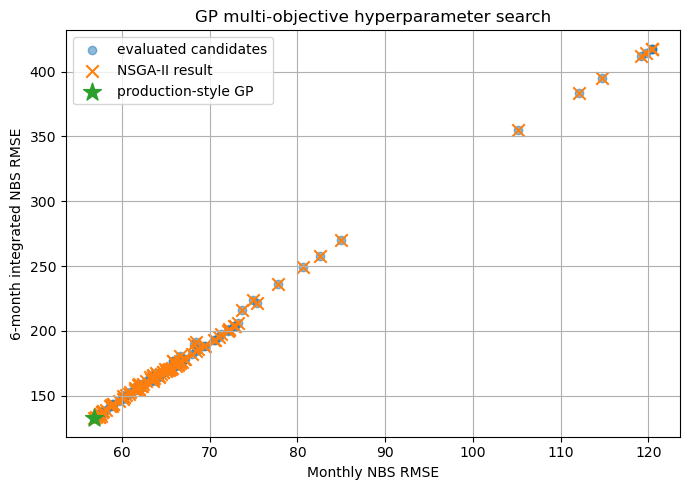

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(
    eval_df["monthly_nbs_rmse"],
    eval_df["six_month_integrated_nbs_rmse"],
    alpha=0.5,
    label="evaluated candidates",
)

plt.scatter(
    pareto_df["monthly_nbs_rmse"],
    pareto_df["six_month_integrated_nbs_rmse"],
    marker="x",
    s=80,
    label="NSGA-II result",
)

plt.scatter(
    baseline_metrics["monthly_nbs_rmse"],
    baseline_metrics["six_month_integrated_nbs_rmse"],
    marker="*",
    s=180,
    label="production-style GP",
)

plt.xlabel("Monthly NBS RMSE")
plt.ylabel("6-month integrated NBS RMSE")
plt.title("GP multi-objective hyperparameter search")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 13. Select and evaluate a candidate

This picks the candidate with the lowest 6-month integrated NBS RMSE. You may instead choose a balanced Pareto point manually.

In [15]:
best = pareto_df.sort_values("six_month_integrated_nbs_rmse").iloc[0]

best_hyperparams = [
    best["matern_length_scale"],
    best["rq_alpha"],
    best["rq_length_scale"],
    best["gp_alpha"],
]

best_gp = build_gp_from_hyperparams(best_hyperparams)
best_gp.fit(X_train_scaled, y_train_scaled)
y_pred_best_scaled = best_gp.predict(X_test_scaled)

best_metrics = evaluate_prediction(y_pred_best_scaled, "multiobjective_gp_selected")

pd.DataFrame([baseline_metrics, best_metrics])

,label,monthly_nbs_rmse,six_month_integrated_nbs_rmse,six_month_integrated_nbs_bias,overall_scaled_r2
0,production_style_gp,56.803424,132.921300,19.449344,0.760849
1,multiobjective_gp_selected,56.863876,132.604084,22.376137,0.760953


## 14. Integrated metrics by lake and window

In [16]:
def integrated_metrics_by_lake(y_true_df, y_pred_df, windows=(1, 3, 6)):
    rows = []

    for lake in lakes:
        cols = [f"{lake}_target_nbs_mo{i}" for i in range(12)]

        yt = y_true_df[cols].to_numpy()
        yp = y_pred_df[cols].to_numpy()

        for window in windows:
            true_integrated = []
            pred_integrated = []

            for start in range(12 - window + 1):
                true_integrated.append(yt[:, start:start + window].sum(axis=1))
                pred_integrated.append(yp[:, start:start + window].sum(axis=1))

            yt_all = np.concatenate(true_integrated)
            yp_all = np.concatenate(pred_integrated)

            rows.append({
                "Lake": lake,
                "Window": window,
                "RMSE": rmse(yt_all, yp_all),
                "R2": r2_score(yt_all, yp_all),
                "Bias": np.mean(yp_all - yt_all),
            })

    return pd.DataFrame(rows)


y_true_df = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_baseline_df = unscale_to_df(y_pred_baseline_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_best_df = unscale_to_df(y_pred_best_scaled, y_scaler, y_test.index, y_test.columns)

integrated_baseline = integrated_metrics_by_lake(y_true_df, y_pred_baseline_df)
integrated_baseline["Model"] = "production_style_gp"

integrated_best = integrated_metrics_by_lake(y_true_df, y_pred_best_df)
integrated_best["Model"] = "multiobjective_gp_selected"

integrated_df = pd.concat([integrated_baseline, integrated_best], ignore_index=True)

integrated_df

,Lake,Window,RMSE,R2,Bias,Model
0,superior,1,35.671631,0.765296,9.924308,production_style_gp
1,superior,3,63.779169,0.866773,31.492529,production_style_gp
2,superior,6,102.359061,0.832564,65.309089,production_style_gp
3,michigan-huron,1,30.476151,0.811208,1.908450,production_style_gp
4,michigan-huron,3,53.346384,0.896046,6.755277,production_style_gp
5,michigan-huron,6,70.174607,0.911244,15.201193,production_style_gp
6,erie,1,78.891195,0.769743,1.164407,production_style_gp
7,erie,3,131.845073,0.883787,4.005942,production_style_gp
8,erie,6,178.496932,0.899554,9.037524,production_style_gp
9,ontario,1,66.943516,0.775224,-2.515635,production_style_gp


In [17]:
integrated_summary = (
    integrated_df
    .groupby(["Model", "Window"], as_index=False)
    .agg(
        RMSE=("RMSE", "mean"),
        R2=("R2", "mean"),
        Bias=("Bias", "mean"),
    )
    .sort_values(["Window", "RMSE"])
)

integrated_summary

,Model,Window,RMSE,R2,Bias
3,production_style_gp,1,52.995623,0.780368,2.620382
0,multiobjective_gp_selected,1,53.087290,0.779330,3.106933
1,multiobjective_gp_selected,3,90.312737,0.883422,10.541804
4,production_style_gp,3,90.638243,0.883061,9.050069
2,multiobjective_gp_selected,6,125.763350,0.886466,22.376137
5,production_style_gp,6,126.007879,0.886349,19.449344


## 15. Plot integrated RMSE and bias

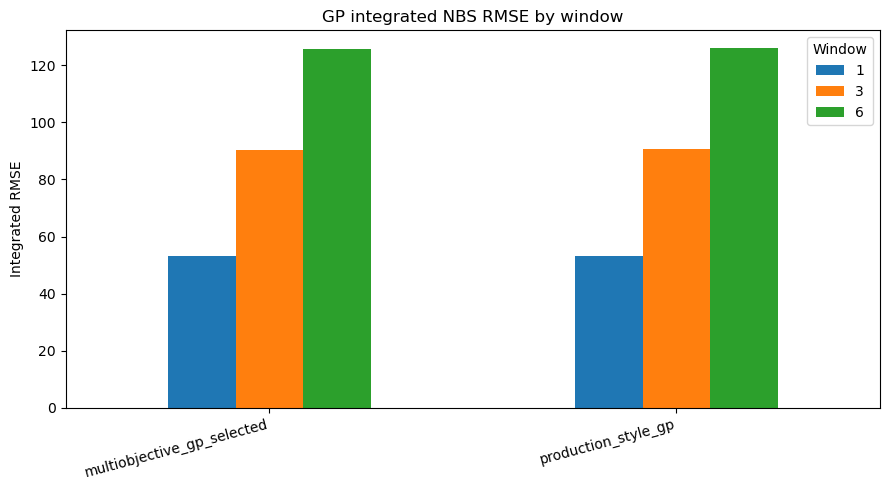

In [18]:
plot_df = integrated_summary.pivot(index="Model", columns="Window", values="RMSE")

ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Integrated RMSE")
ax.set_title("GP integrated NBS RMSE by window")
ax.set_xlabel("")
ax.legend(title="Window")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

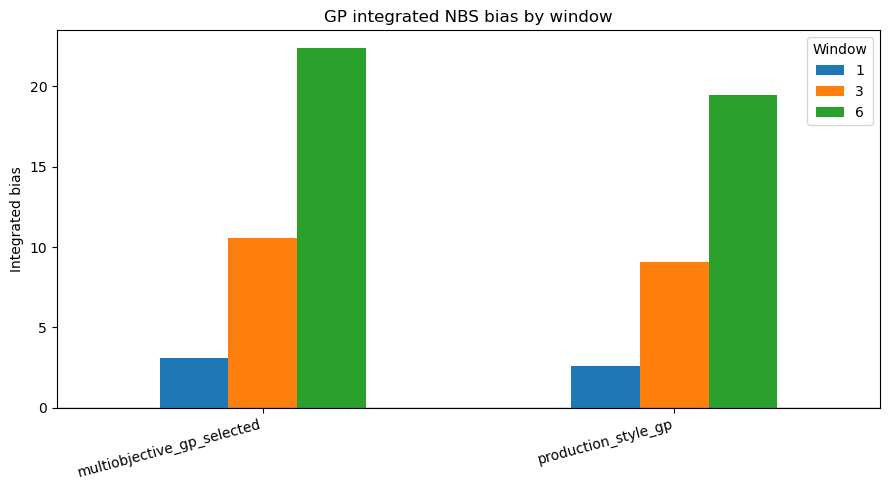

In [19]:
plot_df = integrated_summary.pivot(index="Model", columns="Window", values="Bias")

ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.axhline(0, linewidth=1)
ax.set_ylabel("Integrated bias")
ax.set_title("GP integrated NBS bias by window")
ax.set_xlabel("")
ax.legend(title="Window")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 16. Notes and interpretation

Questions to answer:

- Does multi-objective hyperparameter search improve 6-month integrated NBS RMSE?
- What monthly RMSE tradeoff does it impose?
- Does the selected candidate reduce cumulative bias?
- Does the Pareto front show a meaningful tradeoff, or are objectives aligned?
- Are the candidate hyperparameters physically/plausibly reasonable?
- Should bias be added as a third objective in the next experiment?

Potential next version:

```text
objectives = [
    monthly_nbs_rmse,
    six_month_integrated_nbs_rmse,
    abs(six_month_integrated_nbs_bias)
]
```

In [20]:
# Optional: save outputs
# output_dir = Path(input_dir) / "analysis_outputs"
# output_dir.mkdir(parents=True, exist_ok=True)
# eval_df.to_csv(output_dir / "gp_multiobjective_candidate_log.csv", index=False)
# pareto_df.to_csv(output_dir / "gp_multiobjective_pareto.csv", index=False)
# integrated_df.to_csv(output_dir / "gp_multiobjective_integrated_by_lake.csv", index=False)
# integrated_summary.to_csv(output_dir / "gp_multiobjective_integrated_summary.csv", index=False)